## Test mask exploration #3

In [1]:
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path

In [3]:
# import package develope pour le projet + config
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.optional.development.dataset import IndexedDataset

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
dataset_train = IndexedDataset.create(config, DatasetType.TRAIN)
dataset_train_csv = config.get_csv_filename(DatasetType.TRAIN)
dataset_train_csv = pd.read_csv(dataset_train_csv)

In [5]:
# validation quantite de labels
assert len(dataset_train.species_label) == 5

In [6]:
# inspection visuelle
print(dataset_train.species_label)
print(len(dataset_train.species_label))

['Barn Swallow', 'Common Buzzard', 'Western Yellow Wagtail', 'Thrush Nightingale', 'Willow Warbler']
5


In [7]:
group_length, segment_length_, group_hop_length = config.preprocess.group_frame_infos()
print(group_length, segment_length_, group_hop_length)

60 30 15


In [8]:
# train
print(dataset_train.spectrogram_groups.shape)
print("min:", np.min(dataset_train.spectrogram_groups), ", max:", np.max(dataset_train.spectrogram_groups))

print()

print(dataset_train.spectrogram_mask_groups.shape)
print("min:", np.min(dataset_train.spectrogram_mask_groups), ", max:", np.max(dataset_train.spectrogram_mask_groups))

print()

print(dataset_train.y.shape)
print(dataset_train.y[:5])

num_samples, group_segment_count, n_mels, segment_length = dataset_train.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_train_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_train.lat_long.shape == (num_samples, 2)

np.unique( dataset_train.y )

(4116, 3, 128, 30)
min: -1.0 , max: 6.244573e-08

(4116, 3, 30)
min: 0 , max: 1

(4116, 5)
[[0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]]


array([0, 1], dtype=int16)

In [9]:
# validation distribution especes
print( np.sum( dataset_train.y, axis=0 ) / dataset_train.y.shape[0] )

[0.17274052 0.14285714 0.14115646 0.17808552 0.16180758]


In [10]:
import librosa as rosa
import matplotlib.ticker as mticker

from ffury.optional.development.misc.hdf5 import open_file
from ffury.optional.development.transforms.properties import (
    _SPECTROGRAM,
    _SPECTROGRAM_MASK
)

def colorize_mask(mask, height):
    # appliquer couleur au masque
    image = np.zeros( (mask.shape[0], 3) )

    image[mask == 0] = [1, 0, 0]
    image[mask != 0] = [0, 1, 0]

    # convertir en image avec bonne resolution
    image = image[np.newaxis, ...]
    return np.tile(image, (height, 1, 1))

def specshow(data, data_mask=None, data_mask_alpha=0.1, start_index=0):
    if not start_index is None:
        def update_ticks(x, loc):
            return x + start_index

        plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(update_ticks))

    plt.gca().imshow(data,
                     cmap="gray",
                     aspect="auto",
                     interpolation="nearest",
                     vmin=-1, # spectrogram a un raßnge [0, -1]
                     vmax=0)

    if not data_mask is None:
        mask = colorize_mask(data_mask, data.shape[0])
        plt.gca().imshow(mask,
                         aspect="auto",
                         interpolation="nearest",
                         alpha=data_mask_alpha)

def plot_group(path, start, stop, data_mask_alpha=0.1):
    with open_file(path, "r") as file:
        spectrogram_data = file[_SPECTROGRAM]
        spectrogram_mask_data = file[_SPECTROGRAM_MASK]

        fig = plt.figure(figsize=(12, 4))

        plt.subplot(211)
        specshow(spectrogram_data[:, start:stop],
                 spectrogram_mask_data[start:stop],
                 data_mask_alpha)
        plt.title(f"Group {path.name}, ({start}, {stop})")

        SCALE = 1

        duration = stop - start
        start -= int(duration * SCALE)
        start = max(start, 0)

        stop += int(duration * SCALE)
        stop = min(stop, spectrogram_data.shape[1])

        plt.subplot(212)
        specshow(spectrogram_data[:, start:stop],
                 spectrogram_mask_data[start:stop],
                 data_mask_alpha)
        plt.title(f"Larger group {path.name}, ({start}, {stop})")

        plt.tight_layout()
        plt.show()

def plot_segments(data, data_mask, data_mask_alpha=0.1):
    assert data.shape[0] == data_mask.shape[0]
    assert data.shape[2] == data_mask.shape[1]

    _, _, segment_hop = config.preprocess.group_frame_infos()

    fig = plt.figure(figsize=(12, 2.5))

    num_segments = data.shape[0]
    for s in range(num_segments):
        subplot = f"1{num_segments}{s + 1}"
        plt.subplot(int(subplot))
        specshow(data[s], data_mask[s], data_mask_alpha, s * segment_hop)

    plt.suptitle("Segments")
    plt.tight_layout()
    plt.show()

def validate_data(path, start, stop, data, data_mask):
    _, group_length, segment_hop = config.preprocess.group_frame_infos()

    assert data.shape[2] == group_length
    assert data_mask.shape[1] == group_length

    with open_file(path, "r") as file:
        spectrogram_data = file[_SPECTROGRAM][:, start:stop]
        spectrogram_mask_data = file[_SPECTROGRAM_MASK][start:stop]

        for segment, segment_mask, start in zip(data, data_mask, range(0, len(spectrogram_data), segment_hop)):
            group_data = spectrogram_data[:, start:start + data.shape[2]]
            group_mask_data = spectrogram_mask_data[start:start + data.shape[2]]

            assert np.allclose(group_data, segment)
            assert np.allclose(group_mask_data, segment_mask)

In [11]:
# cibler quelques elements qui sont 'unknown'
unknown = np.argwhere( np.sum(dataset_train.y, axis=-1) == 0 ).flatten()
print( len(unknown) )
print( unknown[:5] )

837
[ 6  9 14 15 18]


label         : [0 0 0 0 0]
label original: [0 0 0 0 1]


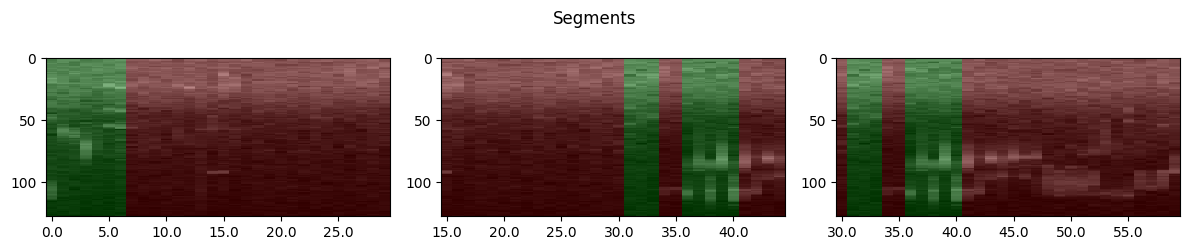

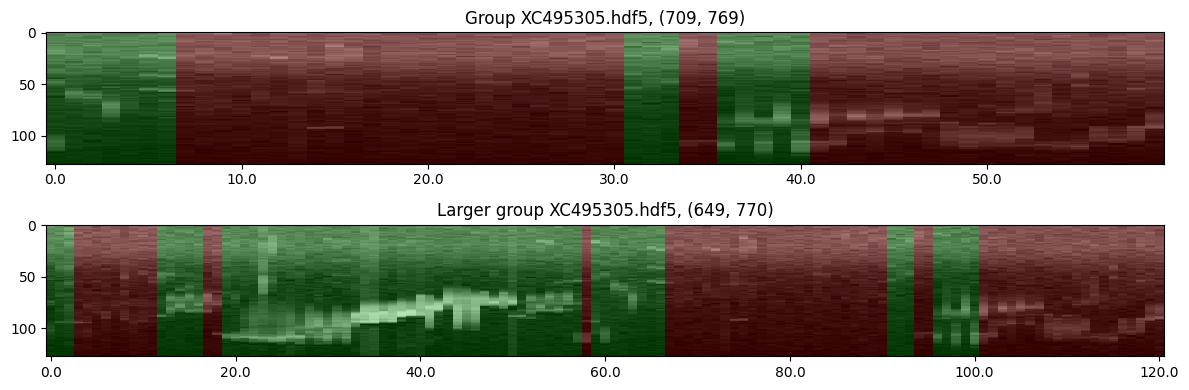

In [12]:
# visualiser les groupes, segments et masque
# note ; si l'indexation change, ces infos doivent changer aussi. Utiliser --log-debug-info

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_train.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC304029.hdf5, 1626, 0, (46, 76)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC304029.hdf5, 1626, 1, (61, 91)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC304029.hdf5, 1626, 2, (76, 106)

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_train.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/eaywag1/XC317370.hdf5, 54, 0, (176, 206)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/eaywag1/XC317370.hdf5, 54, 1, (191, 221)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/eaywag1/XC317370.hdf5, 54, 2, (206, 236)

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_train.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC713573.hdf5, 893, 0, (321, 351)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC713573.hdf5, 893, 1, (336, 366)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC713573.hdf5, 893, 2, (351, 381

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_train.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC495305.hdf5, 6, 0, (709, 739)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC495305.hdf5, 6, 1, (724, 754)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC495305.hdf5, 6, 2, (739, 769)

DATASET = dataset_train
GROUP_INDEX = 6
GROUP_BEGIN = 709
GROUP_END = 769
FILENAME = "wlwwar/XC495305.hdf5"
MASK_ALPHA = 0.2

if False:
    # validation data
    validate_data(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, FILENAME),
                  GROUP_BEGIN,
                  GROUP_END,
                  DATASET.spectrogram_groups[GROUP_INDEX],
                  DATASET.spectrogram_mask_groups[GROUP_INDEX])

print("label         :", DATASET.y[GROUP_INDEX])
print("label original:", DATASET.y_original[GROUP_INDEX])

# visualisation
plot_segments(DATASET.spectrogram_groups[GROUP_INDEX],
              DATASET.spectrogram_mask_groups[GROUP_INDEX],
              MASK_ALPHA)
plot_group(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, FILENAME),
           GROUP_BEGIN,
           GROUP_END,
           MASK_ALPHA)